# ASIC Hardcase Comparison: Visual Inspection

This notebook is a focused visual inspection notebook for **Phase 1 / Chapter 1 / Sprint 3 / Issue 3.2** in ASIC.

Purpose:

- inspect the already assembled stay-level fatal-case comparison dataset
- compare **low-predicted fatal stays** vs **other fatal stays** across the frozen Issue 3.2 variable package
- support human review and interpretation only

Primary input file used:

- `artifacts/chapter1/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison/stay_level_comparison_dataset.csv`

Optional helper input used only for compact descriptive notes if present:

- `artifacts/chapter1/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison/effect_size_plot_data.csv`

This notebook is **descriptive only**:

- no hard-case rule changes
- no new variables
- no p-values
- no formal inference
- no extension beyond the frozen ASIC 24h fatal-stay comparison

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import Markdown, display
except ImportError:
    class Markdown(str):
        pass

    def display(obj):
        print(obj)

plt.style.use('default')
pd.set_option('display.max_colwidth', 120)


def resolve_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise FileNotFoundError('Could not resolve the repository root from the current working directory.')


REPO_ROOT = resolve_repo_root()
ISSUE_DIR = (
    REPO_ROOT
    / 'artifacts'
    / 'chapter1'
    / 'evaluation'
    / 'asic'
    / 'hard_cases'
    / 'primary_medians'
    / 'logistic_regression'
    / 'asic_hard_case_comparison'
)
DATASET_PATH = ISSUE_DIR / 'stay_level_comparison_dataset.csv'
EFFECT_SIZE_PATH = ISSUE_DIR / 'effect_size_plot_data.csv'
COMPARISON_TABLE_PATH = ISSUE_DIR / 'comparison_table.csv'

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        'The assembled Issue 3.2 stay-level comparison dataset was not found at '        f'{DATASET_PATH}. This notebook expects the saved comparison dataset rather than rebuilding it.'
    )

FROZEN_VARIABLES = [
    'age_group',
    'sex',
    'disease_group',
    'prediction_time_h',
    'hospital_id',
    'pf_ratio_last',
    'map_last',
    'creatinine_last',
    'peep_last',
]
CATEGORICAL_VARIABLES = ['age_group', 'sex', 'disease_group', 'hospital_id']
CONTINUOUS_VARIABLES = ['prediction_time_h', 'pf_ratio_last', 'map_last', 'creatinine_last', 'peep_last']
GROUP_ORDER = ['low-predicted fatal stays', 'other fatal stays']
GROUP_COLORS = {
    'low-predicted fatal stays': '#e45756',
    'other fatal stays': '#4c78a8',
}
DISPLAY_LABELS = {
    'age_group': 'Age group',
    'sex': 'Sex',
    'disease_group': 'Disease group',
    'prediction_time_h': 'Prediction time from ICU admission (h)',
    'hospital_id': 'Hospital',
    'pf_ratio_last': 'PF ratio',
    'map_last': 'MAP',
    'creatinine_last': 'Creatinine',
    'peep_last': 'PEEP',
}
ORDERED_LEVELS = {
    'age_group': ['<70', '70-79', '80-130'],
    'sex': ['F', 'M'],
    'disease_group': [
        'surgical / postoperative / trauma-related',
        'respiratory / pulmonary',
        'infection / sepsis non-pulmonary',
        'cardiovascular',
        'neurologic',
        'other / mixed / uncategorized',
    ],
}


def relative_to_repo(path: Path) -> str:
    return str(path.relative_to(REPO_ROOT))

In [2]:
comparison_df = pd.read_csv(DATASET_PATH)
effect_size_df = pd.read_csv(EFFECT_SIZE_PATH) if EFFECT_SIZE_PATH.exists() else None
comparison_table_df = pd.read_csv(COMPARISON_TABLE_PATH) if COMPARISON_TABLE_PATH.exists() else None

provenance_rows = [
    {'input_role': 'Primary comparison dataset', 'path': relative_to_repo(DATASET_PATH), 'exists': DATASET_PATH.exists()},
    {'input_role': 'Saved effect-size helper output', 'path': relative_to_repo(EFFECT_SIZE_PATH), 'exists': EFFECT_SIZE_PATH.exists()},
    {'input_role': 'Saved comparison table', 'path': relative_to_repo(COMPARISON_TABLE_PATH), 'exists': COMPARISON_TABLE_PATH.exists()},
]

display(Markdown('## Setup And Provenance'))
display(pd.DataFrame(provenance_rows))

display(Markdown(
    'This notebook uses the saved Issue 3.2 stay-level comparison dataset and does not rebuild the ASIC hard-case comparison from scratch.'
))

comparison_df.head()

## Setup And Provenance

,input_role,path,exists
0,Primary comparison dataset,artifacts/chapter1/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison...,True
1,Saved effect-size helper output,artifacts/chapter1/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison...,True
2,Saved comparison table,artifacts/chapter1/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison...,True


This notebook uses the saved Issue 3.2 stay-level comparison dataset and does not rebuild the ASIC hard-case comparison from scratch.

,stay_id_global,instance_id,hard_case_flag,hard_case_group,age_group,sex,disease_group,prediction_time_h,hospital_id,pf_ratio_last,map_last,creatinine_last,peep_last
0,asic_UK04_9992,asic_UK04_9992__b11__h24,True,low-predicted fatal stays,70-79,F,respiratory / pulmonary,96,asic_UK04,277.00,86.00,68.069,12.236
1,asic_UK07_9990,asic_UK07_9990__b13__h24,True,low-predicted fatal stays,<70,M,respiratory / pulmonary,112,asic_UK07,NaN,101.20,31.820,NaN
2,asic_UK07_9994,asic_UK07_9994__b115__h24,True,low-predicted fatal stays,70-79,M,respiratory / pulmonary,928,asic_UK07,NaN,69.47,50.390,NaN
3,asic_UK07_9998,asic_UK07_9998__b26__h24,True,low-predicted fatal stays,<70,M,surgical / postoperative / trauma-related,216,asic_UK07,368.57,101.07,40.660,10.100
4,asic_UK02_9992,asic_UK02_9992__b3__h24,False,other fatal stays,<70,M,surgical / postoperative / trauma-related,32,asic_UK02,243.29,105.00,292.000,7.200


## Dataset Sanity Check

This section checks the saved comparison dataset before plotting:

- dataset shape
- group counts
- expected columns
- frozen variable availability
- quick missingness overview

In [3]:
expected_columns = ['stay_id_global', 'instance_id', 'hard_case_flag', 'hard_case_group', *FROZEN_VARIABLES]
missing_expected_columns = sorted(set(expected_columns) - set(comparison_df.columns))
extra_columns = sorted(set(comparison_df.columns) - set(expected_columns))

shape_df = pd.DataFrame(
    [{'rows': int(comparison_df.shape[0]), 'columns': int(comparison_df.shape[1])}]
)
group_counts_df = (
    comparison_df['hard_case_group']
    .value_counts()
    .rename_axis('hard_case_group')
    .reset_index(name='stay_count')
)
variable_presence_df = pd.DataFrame(
    {
        'variable': FROZEN_VARIABLES,
        'present_in_dataset': [variable in comparison_df.columns for variable in FROZEN_VARIABLES],
    }
)
missingness_df = pd.DataFrame(
    {
        'variable': FROZEN_VARIABLES,
        'missing_n': [int(comparison_df[variable].isna().sum()) for variable in FROZEN_VARIABLES],
        'missing_pct': [
            round(100.0 * float(comparison_df[variable].isna().mean()), 1)
            for variable in FROZEN_VARIABLES
        ],
    }
)

print('Missing expected columns:', missing_expected_columns or 'none')
print('Extra columns:', extra_columns or 'none')

display(Markdown('### Dataset shape'))
display(shape_df)

display(Markdown('### Group counts'))
display(group_counts_df)

display(Markdown('### Frozen variable availability'))
display(variable_presence_df)

display(Markdown('### Quick missingness overview'))
display(missingness_df)

display(Markdown('### Columns present'))
display(pd.DataFrame({'column': comparison_df.columns.tolist()}))

Missing expected columns: none
Extra columns: none


### Dataset shape

,rows,columns
0,10,13


### Group counts

,hard_case_group,stay_count
0,other fatal stays,6
1,low-predicted fatal stays,4


...

,variable,present_in_dataset
0,age_group,True
1,sex,True
2,disease_group,True
3,prediction_time_h,True
4,hospital_id,True
5,pf_ratio_last,True
6,map_last,True
7,creatinine_last,True
8,peep_last,True


### Quick missingness overview

,variable,missing_n,missing_pct
0,age_group,0,0.0
1,sex,0,0.0
2,disease_group,0,0.0
3,prediction_time_h,0,0.0
4,hospital_id,0,0.0
5,pf_ratio_last,3,30.0
6,map_last,1,10.0
7,creatinine_last,2,20.0
8,peep_last,3,30.0


### Columns present

,column
0,stay_id_global
1,instance_id
2,hard_case_flag
3,hard_case_group
4,age_group
5,sex
6,disease_group
7,prediction_time_h
8,hospital_id
9,pf_ratio_last


## Categorical Variables

The plots below use grouped proportion bars so the two fatal-case groups are directly comparable despite different group sizes.

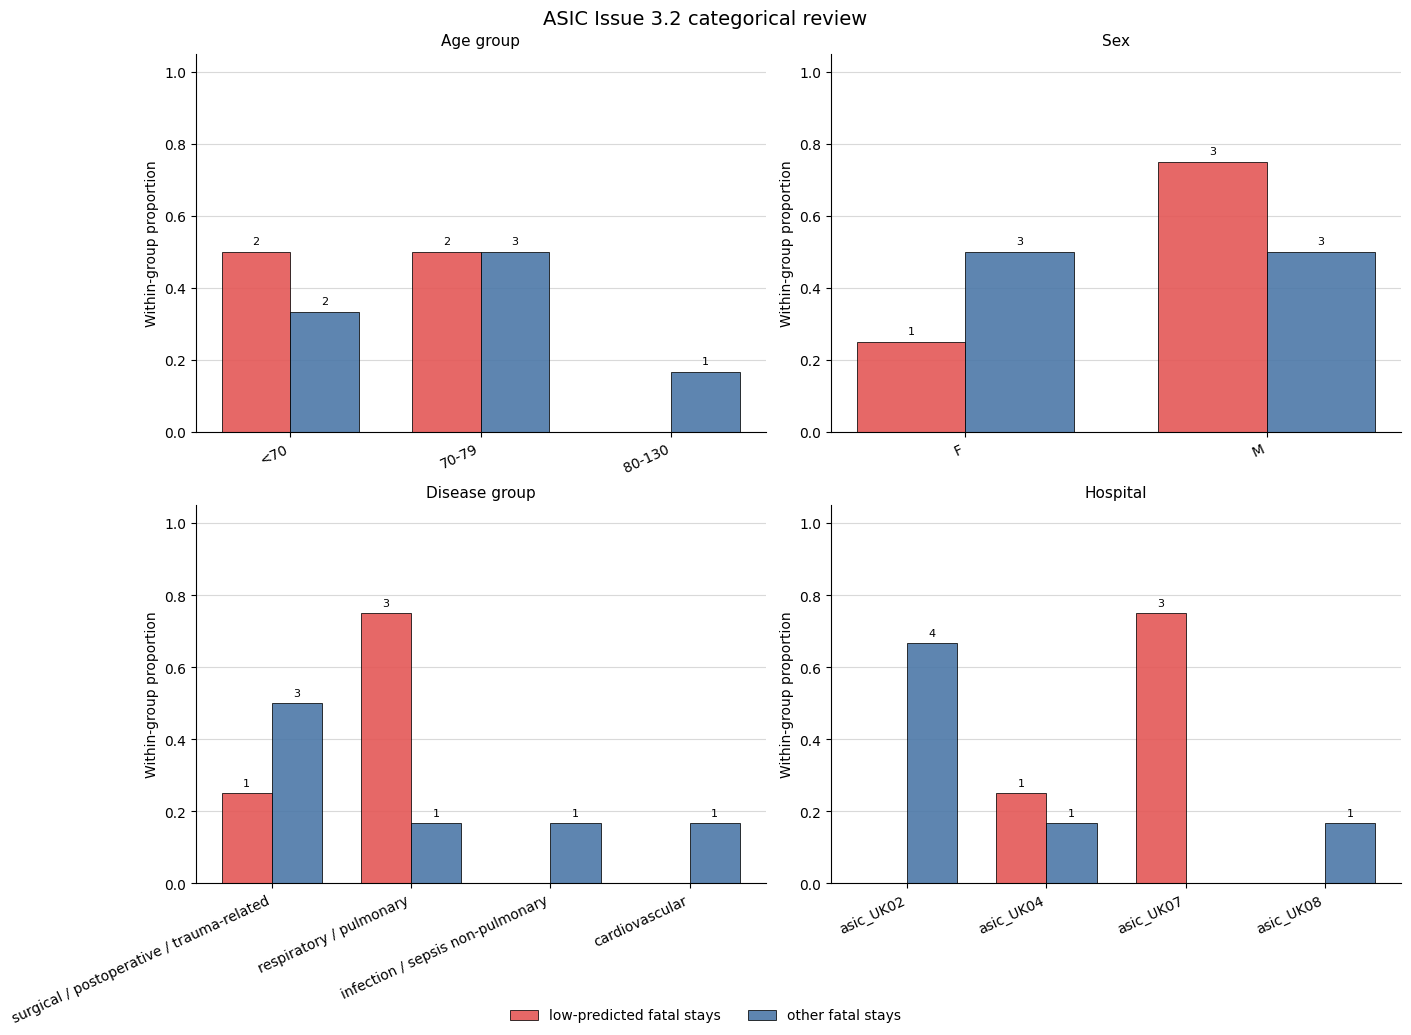

In [9]:
def categorical_levels(frame: pd.DataFrame, variable: str) -> list[str]:
    ordered = ORDERED_LEVELS.get(variable)
    observed = frame[variable].astype('string').fillna('Missing')
    observed_levels = [level for level in observed.unique().tolist() if level != '<NA>']
    if ordered is None:
        levels = sorted(observed_levels)
    else:
        levels = [level for level in ordered if level in observed_levels]
        levels.extend(sorted(level for level in observed_levels if level not in levels))
    if frame[variable].isna().any() and 'Missing' not in levels:
        levels.append('Missing')
    return levels


def grouped_proportion_table(frame: pd.DataFrame, variable: str, levels: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    plot_df = frame[[variable, 'hard_case_group']].copy()
    plot_df[variable] = plot_df[variable].astype('string').fillna('Missing')
    counts = (
        plot_df.groupby(['hard_case_group', variable])
        .size()
        .unstack(fill_value=0)
        .reindex(index=GROUP_ORDER, columns=levels, fill_value=0)
    )
    proportions = counts.div(counts.sum(axis=1), axis=0).fillna(0.0)
    return counts, proportions


def plot_grouped_proportions(ax, frame: pd.DataFrame, variable: str) -> None:
    levels = categorical_levels(frame, variable)
    counts, proportions = grouped_proportion_table(frame, variable, levels)
    x = np.arange(len(levels))
    width = 0.36

    for idx, group in enumerate(GROUP_ORDER):
        offsets = x + (idx - 0.5) * width
        bars = ax.bar(
            offsets,
            proportions.loc[group].to_numpy(),
            width=width,
            label=group,
            color=GROUP_COLORS[group],
            edgecolor='black',
            linewidth=0.6,
            alpha=0.9,
        )
        for bar, level in zip(bars, levels):
            count = int(counts.loc[group, level])
            if count > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    bar.get_height() + 0.015,
                    str(count),
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )

    ax.set_title(DISPLAY_LABELS[variable], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=25, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Within-group proportion')
    ax.grid(axis='y', color='#d9d9d9', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, variable in zip(axes.flat, CATEGORICAL_VARIABLES):
    plot_grouped_proportions(ax, comparison_df, variable)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)
fig.suptitle('ASIC Issue 3.2 categorical review', fontsize=14, y=1.02)
plt.show()

## Continuous Variables

The panels below combine simple boxplots with raw per-stay points so the small-sample distributions remain visible.

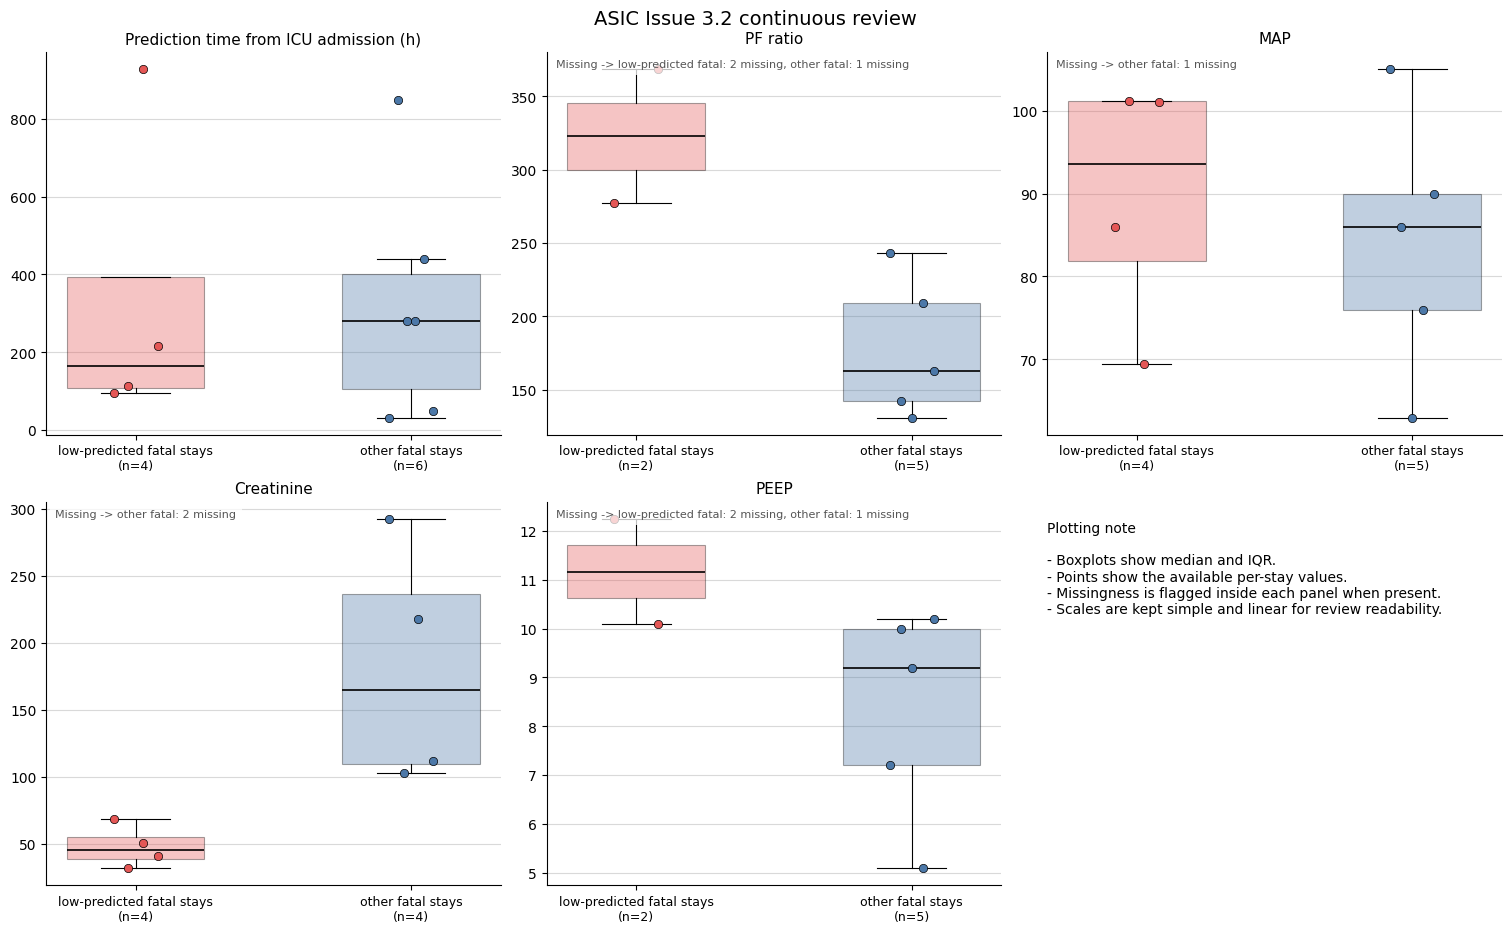

In [5]:
def plot_box_and_points(ax, frame: pd.DataFrame, variable: str) -> None:
    missing_counts = (
        frame.groupby('hard_case_group')[variable]
        .apply(lambda series: int(series.isna().sum()))
        .reindex(GROUP_ORDER, fill_value=0)
    )

    for position, group in enumerate(GROUP_ORDER, start=1):
        values = pd.to_numeric(
            frame.loc[frame['hard_case_group'].eq(group), variable],
            errors='coerce',
        ).dropna()
        color = GROUP_COLORS[group]

        if not values.empty:
            box = ax.boxplot(
                [values.to_numpy()],
                positions=[position],
                widths=0.5,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
            )
            for patch in box['boxes']:
                patch.set(facecolor=color, alpha=0.35, edgecolor='black', linewidth=0.8)
            for median in box['medians']:
                median.set(color='black', linewidth=1.2)
            for whisker in box['whiskers']:
                whisker.set(color='black', linewidth=0.8)
            for cap in box['caps']:
                cap.set(color='black', linewidth=0.8)

            if len(values) == 1:
                jitter = np.array([0.0])
            else:
                jitter = np.linspace(-0.08, 0.08, num=len(values))
            ax.scatter(
                np.full(len(values), position) + jitter,
                values,
                color=color,
                edgecolor='black',
                linewidth=0.5,
                s=36,
                zorder=3,
            )

    labels = []
    for group in GROUP_ORDER:
        observed_n = int(frame.loc[frame['hard_case_group'].eq(group), variable].notna().sum())
        labels.append(f'{group}\n(n={observed_n})')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(DISPLAY_LABELS[variable], fontsize=11)
    ax.grid(axis='y', color='#d9d9d9', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    total_missing = int(missing_counts.sum())
    if total_missing > 0:
        missing_note = ', '.join(
            f"{group.replace(' stays', '')}: {int(missing_counts[group])} missing"
            for group in GROUP_ORDER
            if int(missing_counts[group]) > 0
        )
        ax.text(
            0.02,
            0.98,
            f'Missing -> {missing_note}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=8,
            color='#555555',
            bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
        )


fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
for ax, variable in zip(axes.flat, CONTINUOUS_VARIABLES):
    plot_box_and_points(ax, comparison_df, variable)

axes.flat[-1].axis('off')
axes.flat[-1].text(
    0.0,
    0.95,
    'Plotting note\n\n'
    '- Boxplots show median and IQR.\n'
    '- Points show the available per-stay values.\n'
    '- Missingness is flagged inside each panel when present.\n'
    '- Scales are kept simple and linear for review readability.',
    va='top',
    ha='left',
    fontsize=10,
)
fig.suptitle('ASIC Issue 3.2 continuous review', fontsize=14, y=1.02)
plt.show()

## Compact Summary

The notes below stay intentionally bounded and descriptive. They are meant to help orient visual review, not replace the saved analysis outputs.

In [6]:
def format_name_list(values: list[str]) -> str:
    if not values:
        return 'none'
    if len(values) == 1:
        return values[0]
    if len(values) == 2:
        return f'{values[0]} and {values[1]}'
    return ', '.join(values[:-1]) + f', and {values[-1]}'


summary_lines = []

if effect_size_df is not None and not effect_size_df.empty:
    ranked = effect_size_df.dropna(subset=['absolute_standardized_difference']).sort_values(
        'absolute_standardized_difference',
        ascending=False,
        kind='stable',
    )
    top_visual = ranked.head(3)['figure_label'].astype(str).tolist()
    lower_visual = ranked.sort_values(
        'absolute_standardized_difference',
        ascending=True,
        kind='stable',
    ).head(2)['figure_label'].astype(str).tolist()
    summary_lines.append(
        'Variables that look most different in the saved helper output: ' + format_name_list(top_visual) + '.'
    )
    summary_lines.append(
        'Variables that look more similar in the saved helper output: ' + format_name_list(lower_visual) + '.'
    )
else:
    summary_lines.append('Saved effect-size helper output was not available, so the notebook summary is based on the plots alone.')

missingness = comparison_df[FROZEN_VARIABLES].isna().sum().sort_values(ascending=False)
missing_variables = [
    f'`{variable}` ({int(count)}/{len(comparison_df)} missing)'
    for variable, count in missingness.items()
    if int(count) > 0
]
if missing_variables:
    summary_lines.append(
        'Missingness may affect interpretation most for ' + format_name_list(missing_variables) + '.'
    )
else:
    summary_lines.append('No missingness was present in the frozen variable package.')

summary_lines.append(
    'Treat all visual patterns as descriptive only because the saved ASIC 24h fatal-stay slice is small '
    f'(n={len(comparison_df)} total stays).'
)

display(Markdown('## Review Notes\n\n' + '\n'.join(f'- {line}' for line in summary_lines)))

## Review Notes

- Variables that look most different in the saved helper output: PF ratio, Hospital (asic_UK07), and Creatinine.
- Variables that look more similar in the saved helper output: Prediction time from ICU admission (h) and MAP.
- Missingness may affect interpretation most for `pf_ratio_last` (3/10 missing), `peep_last` (3/10 missing), `creatinine_last` (2/10 missing), and `map_last` (1/10 missing).
- Treat all visual patterns as descriptive only because the saved ASIC 24h fatal-stay slice is small (n=10 total stays).